In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
DATA_DIR = Path.cwd().parent/'data'

In [4]:
drivers = pd.read_csv(DATA_DIR/'drivers.csv')
drivers.head(10)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
5,6,nakajima,\N,NAK,Kazuki,Nakajima,1985-01-11,Japanese,http://en.wikipedia.org/wiki/Kazuki_Nakajima
6,7,bourdais,\N,BOU,Sébastien,Bourdais,1979-02-28,French,http://en.wikipedia.org/wiki/S%C3%A9bastien_Bo...
7,8,raikkonen,7,RAI,Kimi,Räikkönen,1979-10-17,Finnish,http://en.wikipedia.org/wiki/Kimi_R%C3%A4ikk%C...
8,9,kubica,88,KUB,Robert,Kubica,1984-12-07,Polish,http://en.wikipedia.org/wiki/Robert_Kubica
9,10,glock,\N,GLO,Timo,Glock,1982-03-18,German,http://en.wikipedia.org/wiki/Timo_Glock


In [5]:
drivers.isna().sum()

driverId       0
driverRef      0
number         0
code           0
forename       0
surname        0
dob            0
nationality    0
url            0
dtype: int64

In [6]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     861 non-null    int64 
 1   driverRef    861 non-null    object
 2   number       861 non-null    object
 3   code         861 non-null    object
 4   forename     861 non-null    object
 5   surname      861 non-null    object
 6   dob          861 non-null    object
 7   nationality  861 non-null    object
 8   url          861 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.7+ KB


In [7]:
drivers['dob'] = pd.to_datetime(drivers['dob'])
drivers.dtypes

driverId                int64
driverRef              object
number                 object
code                   object
forename               object
surname                object
dob            datetime64[ns]
nationality            object
url                    object
dtype: object

In [8]:
drivers["full_name"] = drivers['forename'] + " " + drivers['surname']
drivers.head(10)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url,full_name
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,Lewis Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,Nick Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,Nico Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,Fernando Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,Heikki Kovalainen
5,6,nakajima,\N,NAK,Kazuki,Nakajima,1985-01-11,Japanese,http://en.wikipedia.org/wiki/Kazuki_Nakajima,Kazuki Nakajima
6,7,bourdais,\N,BOU,Sébastien,Bourdais,1979-02-28,French,http://en.wikipedia.org/wiki/S%C3%A9bastien_Bo...,Sébastien Bourdais
7,8,raikkonen,7,RAI,Kimi,Räikkönen,1979-10-17,Finnish,http://en.wikipedia.org/wiki/Kimi_R%C3%A4ikk%C...,Kimi Räikkönen
8,9,kubica,88,KUB,Robert,Kubica,1984-12-07,Polish,http://en.wikipedia.org/wiki/Robert_Kubica,Robert Kubica
9,10,glock,\N,GLO,Timo,Glock,1982-03-18,German,http://en.wikipedia.org/wiki/Timo_Glock,Timo Glock


In [9]:
drivers['nationality'].value_counts()

nationality
British              166
American             158
Italian               99
French                73
German                50
Brazilian             32
Argentine             24
Belgian               23
Swiss                 23
South African         23
Japanese              20
Australian            19
Dutch                 18
Austrian              15
Spanish               15
Canadian              14
Swedish               10
New Zealander         10
Finnish                9
Mexican                6
Danish                 5
Irish                  5
Uruguayan              4
Rhodesian              4
Monegasque             4
Portuguese             4
Russian                4
Venezuelan             3
Colombian              3
East German            3
Thai                   2
Indian                 2
Polish                 1
Hungarian              1
Malaysian              1
Czech                  1
American-Italian       1
Chilean                1
Liechtensteiner        1
Argentine-Ita

Show 10 most represented countries in Formula1

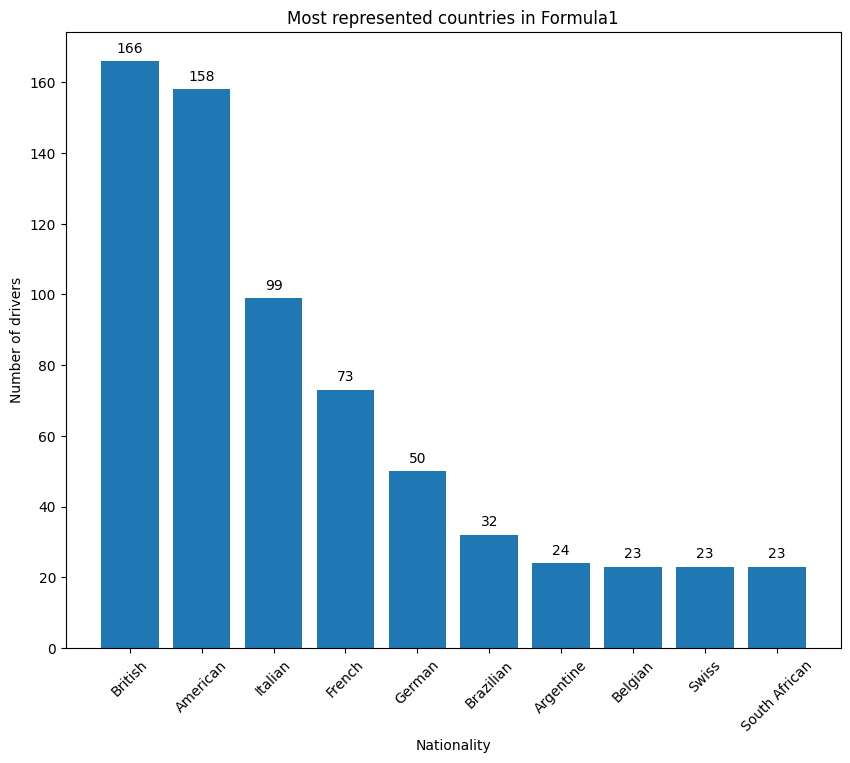

In [10]:
top10_nationalities = drivers['nationality'].value_counts().head(10)

nations = top10_nationalities.index.tolist()
number = top10_nationalities.values.tolist()

fig, ax = plt.subplots(figsize=(10,8))
bars = ax.bar(nations,number)
ax.tick_params(axis='x', labelrotation=45)
ax.set_title('Most represented countries in Formula1')
ax.set_xlabel('Nationality')
ax.set_ylabel('Number of drivers')

for bar in bars:
    height = bar.get_height()
    offset = max(top10_nationalities.values) * 0.01
    ax.text(bar.get_x() + bar.get_width()/2., height+offset, int(height), ha='center', va='bottom')

plt.show()


In [11]:
drivers.to_csv(DATA_DIR/'processed_data/clean_drivers.csv', index=False)

Saving processed data into new file in special folder for processed data.